In [70]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from catboost import CatBoostClassifier

In [71]:
seed = 42
root_path = "/home/stefan/ioai-prep/kits/academic_status_pred"

# Data

In [72]:
def prep_df(df: pd.DataFrame, fit_columns=None):
    df = df.drop(["SampleID", "Target"], axis=1, errors="ignore")

    obj_col = df.select_dtypes(include=["object"])
    for col in obj_col:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummies], axis=1)
    df = df.drop(obj_col, axis=1)

    if fit_columns is not None:
        # Add missing columns with 0
        missing_cols = set(fit_columns) - set(df.columns)
        for col in missing_cols:
            df[col] = 0
        # Reorder to match training
        df = df[fit_columns]

    return df

In [73]:
df = pd.read_csv(f"{root_path}/train.csv")
df_train = prep_df(df)
y = df["Target"]

<Axes: xlabel='Target'>

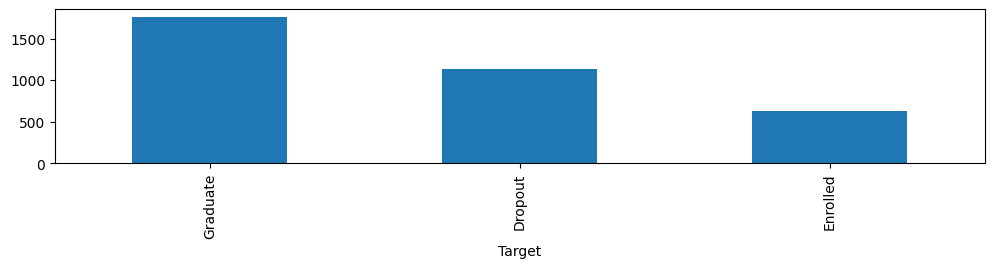

In [74]:
plt.figure(figsize=(12, 2))
y.value_counts().plot(kind="bar")

# Model

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    df_train, y, test_size=0.2, random_state=seed, stratify=y
)

In [76]:
def evaluate(model):
    cv = cross_val_score(model, X_train, y_train, scoring="f1_macro", cv=3, n_jobs=-1)
    cv_score = cv.mean().item()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = f1_score(y_test, preds, average="macro")

    return cv_score, score

In [77]:
log = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=1000, class_weight="balanced", random_state=seed
            ),
        ),
    ]
)
evaluate(log)

(0.7049570299117076, 0.7048228186298552)

In [78]:
svc = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LinearSVC(C=1.0, max_iter=5000, random_state=seed, class_weight="balanced"),
        ),
    ]
)
evaluate(svc)

(0.691826744656916, 0.6991491543511513)

In [79]:
cb = CatBoostClassifier(
    random_seed=seed,
    iterations=1000,
    learning_rate=0.05,
    depth=6,
)

evaluate(cb)

0:	learn: 1.0648880	total: 6.07ms	remaining: 6.06s
0:	learn: 1.0600114	total: 4.61ms	remaining: 4.61s
1:	learn: 1.0328311	total: 11ms	remaining: 5.46s
1:	learn: 1.0275490	total: 9.92ms	remaining: 4.95s
2:	learn: 1.0023646	total: 14.4ms	remaining: 4.8s
0:	learn: 1.0622614	total: 8.97ms	remaining: 8.97s
3:	learn: 0.9749316	total: 17.1ms	remaining: 4.26s
2:	learn: 0.9973375	total: 14.9ms	remaining: 4.94s
4:	learn: 0.9484368	total: 21.1ms	remaining: 4.21s
3:	learn: 0.9678958	total: 18.7ms	remaining: 4.64s
1:	learn: 1.0300074	total: 17ms	remaining: 8.5s
4:	learn: 0.9422237	total: 22ms	remaining: 4.37s
2:	learn: 0.9979931	total: 20.5ms	remaining: 6.82s
5:	learn: 0.9258948	total: 27.3ms	remaining: 4.52s
5:	learn: 0.9200106	total: 26.8ms	remaining: 4.44s
3:	learn: 0.9719138	total: 24.3ms	remaining: 6.06s
6:	learn: 0.9052706	total: 33.5ms	remaining: 4.75s
6:	learn: 0.8983719	total: 31.3ms	remaining: 4.43s
4:	learn: 0.9441369	total: 29.4ms	remaining: 5.85s
7:	learn: 0.8796867	total: 35.6ms	remai

(0.691655514624404, 0.708297022433468)

In [80]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=seed,
    n_jobs=-1,
    max_depth=10,
    class_weight="balanced",
)
rf_param_grid = {"n_estimators": [100, 200], "max_depth": [8, 10, None]}
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring="f1_macro", n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_
print(f"Best RF params: {rf_grid.best_params_}")
evaluate(rf)

Best RF params: {'max_depth': 10, 'n_estimators': 200}


(0.7038577923362758, 0.698393068006027)

In [81]:
stack = StackingClassifier(
    estimators=[("log", log), ("svc", svc), ("cb", cb), ("rf", rf)],
    final_estimator=LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=seed
    ),
    cv=5,
    n_jobs=-1,
)
evaluate(stack)

0:	learn: 1.0600114	total: 45.6ms	remaining: 45.6s
0:	learn: 1.0648880	total: 43.9ms	remaining: 43.8s
1:	learn: 1.0275490	total: 70.4ms	remaining: 35.1s
1:	learn: 1.0328311	total: 71.5ms	remaining: 35.7s
2:	learn: 0.9973375	total: 96.9ms	remaining: 32.2s
2:	learn: 1.0023646	total: 78ms	remaining: 25.9s
0:	learn: 1.0622614	total: 98.6ms	remaining: 1m 38s
1:	learn: 1.0300074	total: 103ms	remaining: 51.6s
3:	learn: 0.9749316	total: 94.1ms	remaining: 23.4s
3:	learn: 0.9678958	total: 119ms	remaining: 29.6s
4:	learn: 0.9484368	total: 103ms	remaining: 20.4s
2:	learn: 0.9979931	total: 115ms	remaining: 38.4s
3:	learn: 0.9719138	total: 120ms	remaining: 30s
5:	learn: 0.9258948	total: 113ms	remaining: 18.7s
4:	learn: 0.9441369	total: 126ms	remaining: 25s
4:	learn: 0.9422237	total: 136ms	remaining: 27.1s
6:	learn: 0.9052706	total: 118ms	remaining: 16.8s
7:	learn: 0.8865235	total: 125ms	remaining: 15.5s
5:	learn: 0.9200106	total: 146ms	remaining: 24.2s
5:	learn: 0.9249214	total: 138ms	remaining: 22.

(0.7164629761985258, 0.7053548484611145)

In [82]:
model = stack
model.fit(X_train, y_train)

0:	learn: 1.0583520	total: 3.7ms	remaining: 3.69s
1:	learn: 1.0231784	total: 11ms	remaining: 5.49s
2:	learn: 0.9920480	total: 17.8ms	remaining: 5.93s
3:	learn: 0.9635823	total: 22.9ms	remaining: 5.7s
4:	learn: 0.9366816	total: 29.1ms	remaining: 5.8s
5:	learn: 0.9149623	total: 35.4ms	remaining: 5.87s
6:	learn: 0.8929529	total: 39.2ms	remaining: 5.55s
7:	learn: 0.8736973	total: 42.9ms	remaining: 5.32s
8:	learn: 0.8540194	total: 46.2ms	remaining: 5.09s
9:	learn: 0.8365237	total: 49.2ms	remaining: 4.87s
10:	learn: 0.8233655	total: 52.5ms	remaining: 4.72s
11:	learn: 0.8097061	total: 56.3ms	remaining: 4.64s
12:	learn: 0.7971931	total: 60.7ms	remaining: 4.61s
13:	learn: 0.7848286	total: 64.4ms	remaining: 4.54s
14:	learn: 0.7737749	total: 67.2ms	remaining: 4.41s
15:	learn: 0.7627113	total: 70.8ms	remaining: 4.35s
16:	learn: 0.7541256	total: 74.1ms	remaining: 4.29s
17:	learn: 0.7449195	total: 79ms	remaining: 4.31s
18:	learn: 0.7361196	total: 82.6ms	remaining: 4.26s
19:	learn: 0.7277810	total: 8

StackingClassifier(cv=5,
                   estimators=[('log',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 LogisticRegression(class_weight='balanced',
                                                                    max_iter=1000,
                                                                    random_state=42))])),
                               ('svc',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 LinearSVC(class_weight='balanced',
                                                           max_iter=5000,
                                                           random_state=42))])),
                               ('cb',
                                <catboost.core.CatBoostClassifier object at 0x7faed8476210>),
                               ('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=10,
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1)

# Submission

In [86]:
df_test = pd.read_csv(f"{root_path}/test.csv")
submission = df_test[["SampleID"]]
df_test = prep_df(df_test, df_train.columns)

In [87]:
submission["Target"] = model.predict(df_test).reshape(-1)
submission.head()

,SampleID,Target
0,1853,Graduate
1,2399,Graduate
2,510,Dropout
3,242,Graduate
4,3392,Graduate


In [88]:
submission.to_csv(f"{root_path}/submission.csv", index=False)